In [1]:
import pandas as pd
import numpy as np
import sklearn

print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("Scikit-Learn Loaded Successfully")

Pandas Version: 2.2.2
NumPy Version: 2.0.2
Scikit-Learn Loaded Successfully


In [2]:
import pandas as pd

df = pd.read_csv('diabetes.csv')  # replace with your exact file name if different

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (614, 8)
Testing Data: (154, 8)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [8]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 74.68 %


In [9]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Prediction: 0
Not Diabetic


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[78 21]
 [18 37]]


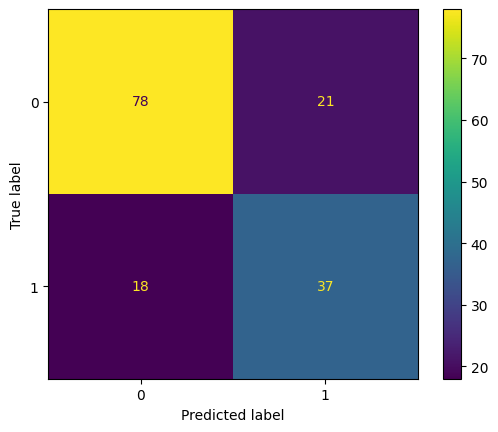

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [13]:
new_patient = [[2,120,70,20,79,25.0,0.35,30]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Patient is likely Diabetic")
else:
    print("Patient is likely Not Diabetic")

Patient is likely Not Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [14]:
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

print("Model Saved Successfully!")

Model Saved Successfully!
